### Importing libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf

In [2]:
test_dataset_path = "pneumonia_detection/test"

test_img_path = []
test_labels = []

class_names = ["NORMAL", "PNEUMONIA"]

for label, class_name in enumerate(class_names):
  class_dir = os.path.join(test_dataset_path, class_name)

  for file in os.listdir(class_dir):
    test_img_path.append(os.path.join(class_dir, file))
    test_labels.append(label)

In [3]:
test_data = tf.data.Dataset.from_tensor_slices((test_img_path, test_labels))

In [4]:
def preprocessing(path, label):
  image = tf.io.read_file(path)
  image = tf.image.decode_jpeg(image, channels=3)
  image = tf.image.resize(image, ((224,224)))
  image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
  return image, label

In [5]:
test_data = test_data.map(preprocessing, num_parallel_calls=tf.data.AUTOTUNE)
test_data = test_data.batch(32)
test_data = test_data.prefetch(tf.data.AUTOTUNE)

### Loading the model from saved .keras file

In [6]:
import tensorflow as tf

model = tf.keras.models.load_model("mobilenet_finetuned.keras")

We use the next cell to find out the name of the last convolution layer so that we can reference it while building the GradCAM pipeline

In [7]:
for layer in model.layers: print(layer.name, layer.output.shape)

mobilenetv2_1.00_224 (None, 7, 7, 1280)
global_average_pooling2d (None, 1280)
dense (None, 128)
dropout (None, 128)
dense_1 (None, 1)


In [8]:
base_model = model.get_layer("mobilenetv2_1.00_224")

for layer in base_model.layers:
    print(layer.name, layer.output.shape)

input_layer (None, 224, 224, 3)
Conv1 (None, 112, 112, 32)
bn_Conv1 (None, 112, 112, 32)
Conv1_relu (None, 112, 112, 32)
expanded_conv_depthwise (None, 112, 112, 32)
expanded_conv_depthwise_BN (None, 112, 112, 32)
expanded_conv_depthwise_relu (None, 112, 112, 32)
expanded_conv_project (None, 112, 112, 16)
expanded_conv_project_BN (None, 112, 112, 16)
block_1_expand (None, 112, 112, 96)
block_1_expand_BN (None, 112, 112, 96)
block_1_expand_relu (None, 112, 112, 96)
block_1_pad (None, 113, 113, 96)
block_1_depthwise (None, 56, 56, 96)
block_1_depthwise_BN (None, 56, 56, 96)
block_1_depthwise_relu (None, 56, 56, 96)
block_1_project (None, 56, 56, 24)
block_1_project_BN (None, 56, 56, 24)
block_2_expand (None, 56, 56, 144)
block_2_expand_BN (None, 56, 56, 144)
block_2_expand_relu (None, 56, 56, 144)
block_2_depthwise (None, 56, 56, 144)
block_2_depthwise_BN (None, 56, 56, 144)
block_2_depthwise_relu (None, 56, 56, 144)
block_2_project (None, 56, 56, 24)
block_2_project_BN (None, 56, 56, 24

In [9]:
last_conv_layer_name = "out_relu"

### Building the GradCAM pipeline

In [24]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Run this once after training, before Grad-CAM
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation="sigmoid")(x)

functional_model = tf.keras.Model(inputs=inputs, outputs=outputs)
functional_model.set_weights(model.get_weights())  # transfer trained weights

In [34]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    backbone = model.get_layer("mobilenetv2_1.00_224")

    grad_model = tf.keras.Model(
        inputs=backbone.input,
        outputs=[
            backbone.get_layer(last_conv_layer_name).output,
            backbone.output
        ]
    )

    # Get head layers by type, not by index
    gap_layer = next(l for l in model.layers if isinstance(l, tf.keras.layers.GlobalAveragePooling2D))
    dense_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.Dense)]
    dropout_layer = next(l for l in model.layers if isinstance(l, tf.keras.layers.Dropout))

    with tf.GradientTape() as tape:
        conv_outputs, backbone_out = grad_model(img_array)
        x = gap_layer(backbone_out)
        x = dense_layers[0](x)
        x = dropout_layer(x)
        preds = dense_layers[1](x)
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

#### Building a helper function to overlay the GradCAM heatmap on input test image





In [11]:
def overlay_gradcam(original_img, heatmap, alpha=0.4):

    heatmap = tf.image.resize(
        heatmap[..., tf.newaxis],
        original_img.shape[:2]
    )

    heatmap = tf.squeeze(heatmap)

    colormap = plt.get_cmap("jet")
    colored_heatmap = colormap(heatmap.numpy())[:, :, :3]

    overlay = alpha * colored_heatmap + original_img
    overlay = overlay / np.max(overlay)

    return overlay

#### Building a helper function to display GradCAM heatmap along with input test image, model prediction and true label

In [12]:
def show_gradcam_result(
    original_img,
    heatmap,
    pred_prob=None,
    true_label=None,
    alpha=0.4
):
    # Resize heatmap
    resized_heatmap = tf.image.resize(
        heatmap[..., tf.newaxis],
        original_img.shape[:2]
    )
    resized_heatmap = tf.squeeze(resized_heatmap).numpy()

    # Apply colormap
    cmap = plt.get_cmap("jet")
    colored_heatmap = cmap(resized_heatmap)[:, :, :3]

    # Overlay
    overlay = alpha * colored_heatmap + original_img
    overlay = overlay / np.max(overlay)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(original_img)
    axes[0].set_title("Original X-ray")
    axes[0].axis("off")

    axes[1].imshow(resized_heatmap, cmap="jet")
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    # Metadata title
    title_parts = []
    if pred_prob is not None:
        title_parts.append(f"Pred Pneumonia Prob: {pred_prob:.3f}")
    if true_label is not None:
        label_name = "PNEUMONIA" if true_label == 1 else "NORMAL"
        title_parts.append(f"True Label: {label_name}")

    if title_parts:
        fig.suptitle(" | ".join(title_parts), fontsize=14)

    plt.tight_layout()
    plt.show()

#### Helper function that automatically takes a batch from test dataset based on user input, selects a particular image with the given index and displays GradCAM results

In [47]:
def get_gradcam(img_index, batch_number):
    for images, labels in test_data.take(batch_number):
      img = images[img_index]
      true_label = labels[0].numpy()

    img_array = tf.expand_dims(img, axis=0)

    pred_prob = functional_model.predict(img_array)[0][0]

    last_conv_layer_name = "out_relu"  # or whatever you have

    heatmap = make_gradcam_heatmap(
        img_array,
        functional_model,   # ← pass functional_model here
        last_conv_layer_name
    )

    display_img = (img.numpy() + 1) / 2

    show_gradcam_result(
      display_img,
      heatmap,
      pred_prob,
      true_label
  )



### Applying GradCAM on our test dataset and model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


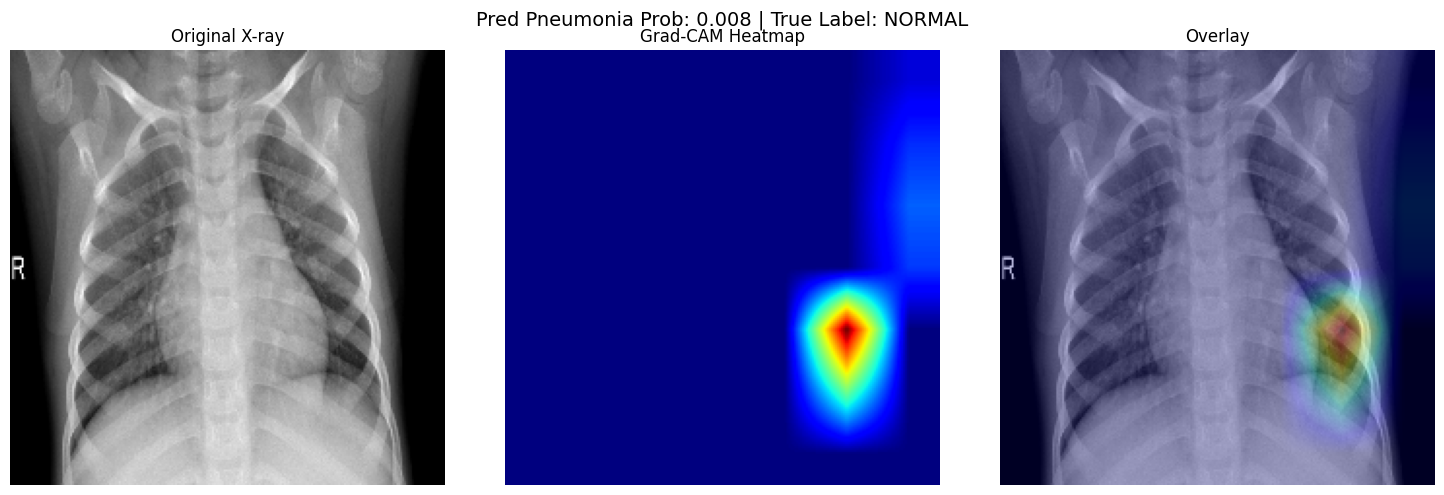

In [55]:
get_gradcam(7, 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


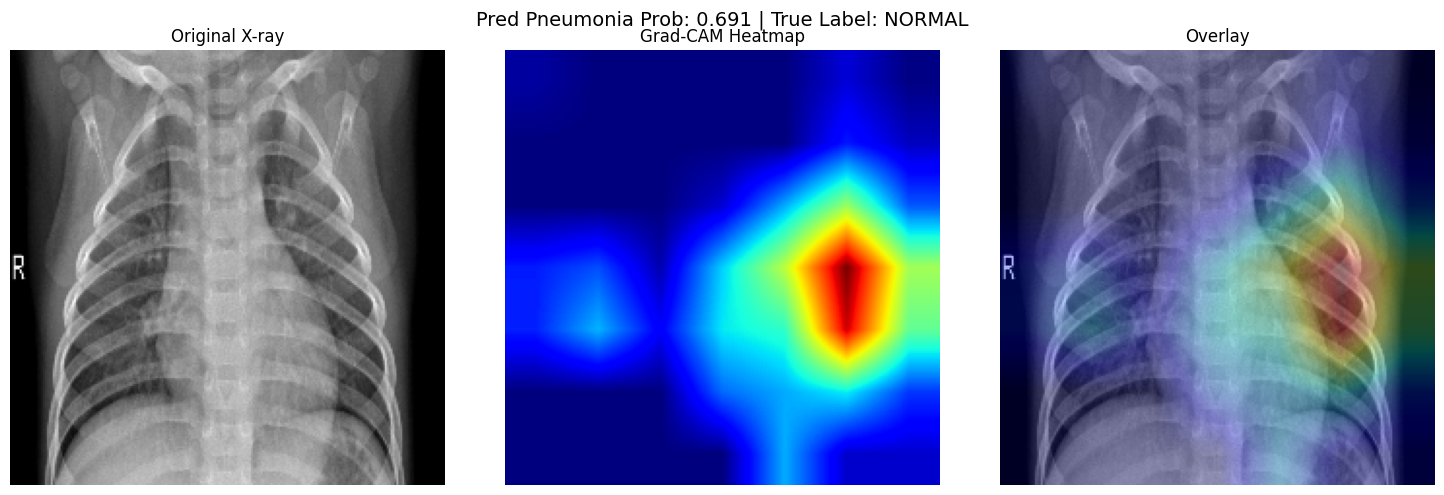

In [59]:
get_gradcam(19,1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


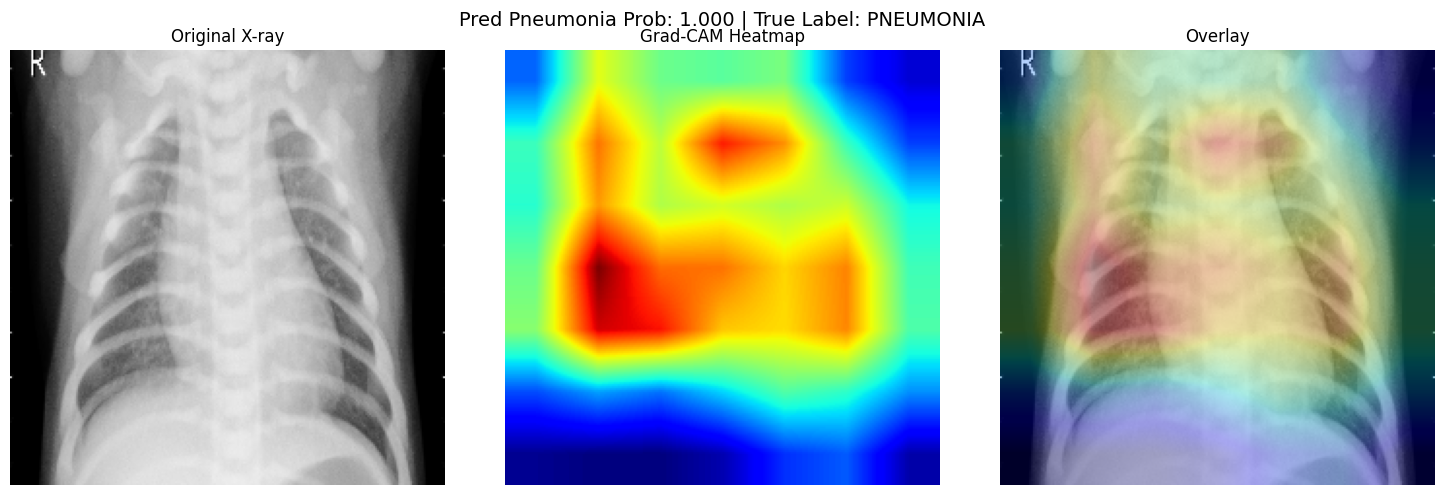

In [50]:
get_gradcam(6,10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


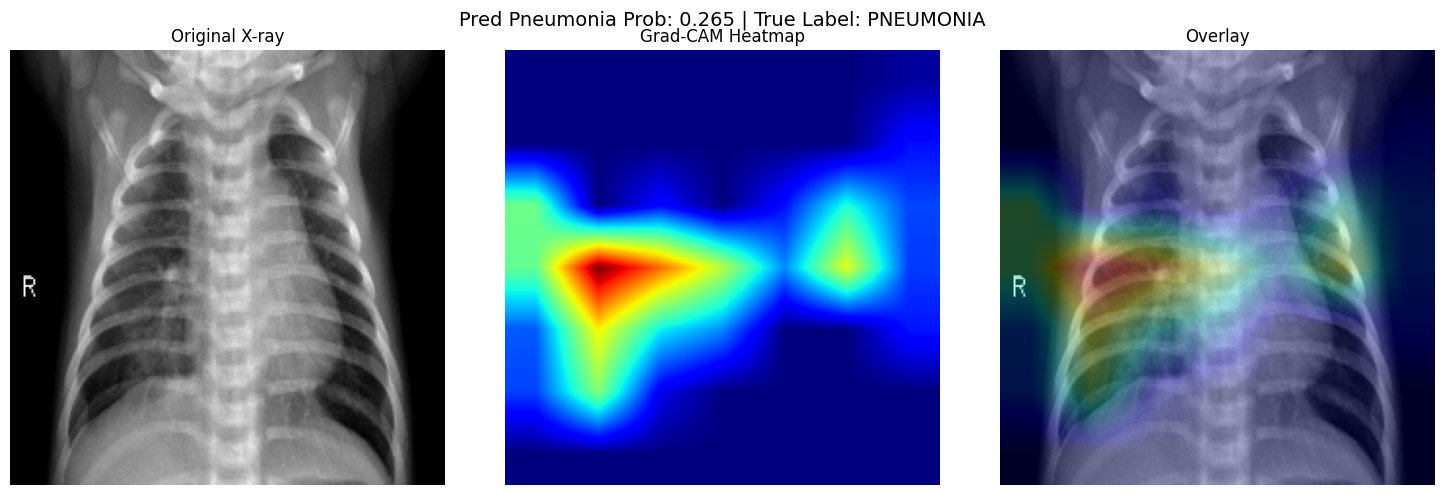

In [51]:
get_gradcam(13,10)